# Analyze deconvolved gene expression

In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner

output_directory = 'output/prototype_pipeline_subset/'


In [69]:
from pipeline.expression_analysis import load_deconvolved_gene_expression, \
    plot_volcano_cg1_dg1

deconvolved_genes_F = load_deconvolved_gene_expression(output_directory)

In [70]:
deconvolved_genes_F

,0,1,2,3,4,5,6,7,8,9,...,139,140,141,142,143,144,145,146,147,148
YBR046C,5.829210,5.945749,6.062994,6.180331,6.296598,6.410479,6.522529,6.633668,6.743293,6.851112,...,4.781844,4.747812,4.714312,4.681733,4.651449,4.624699,4.603071,4.588032,4.579088,5.829210
YHR028C,7.156002,7.106190,7.054791,7.005384,6.959217,6.917643,6.884010,6.861041,6.852861,6.863213,...,6.303680,6.296964,6.290084,6.283082,6.276173,6.269565,6.263491,6.258173,6.253572,7.156002
YHR003C,6.859522,6.628190,6.380242,6.136266,5.897340,5.665492,5.466203,5.321893,5.260198,5.308940,...,6.234321,6.237508,6.240225,6.242385,6.243768,6.244203,6.243416,6.241164,6.237586,6.859522
YBR179C,5.525431,5.391078,5.247928,5.106471,4.967351,4.831636,4.712406,4.621242,4.572322,4.579872,...,4.859433,4.863555,4.867807,4.872165,4.876503,4.880700,4.884618,4.888130,4.891252,5.525431
YCR066W,4.649370,4.519975,4.315467,4.093529,3.947366,3.971471,4.113847,4.296827,4.440606,4.458993,...,4.046277,4.047615,4.048912,4.050151,4.051273,4.052226,4.052942,4.053359,4.053501,4.649370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YHR152W,8.442857,8.160233,7.869927,7.578654,7.287801,6.998371,6.719767,6.461105,6.232404,6.043309,...,5.249135,5.386410,5.521762,5.653621,5.777027,5.887516,5.979384,6.047347,6.093006,8.442857
YDR292C,6.813593,6.709412,6.562799,6.408972,6.302459,6.298620,6.369063,6.470199,6.558007,6.584572,...,6.707852,6.702089,6.696042,6.689733,6.683314,6.676944,6.670783,6.664983,6.659545,6.813593
YBR236C,6.422878,6.371840,6.320269,6.269930,6.221337,6.174981,6.132880,6.096848,6.069154,6.051923,...,6.116929,6.119272,6.121615,6.123935,6.126146,6.128166,6.129898,6.131250,6.132247,6.422878
YJL006C,5.072622,4.866362,4.650018,4.439599,4.238229,4.049993,3.891528,3.776495,3.724754,3.755526,...,5.375172,5.358259,5.339130,5.317676,5.294051,5.268534,5.241186,5.212102,5.181595,5.072622


Shifting mu0, gamma1, and gamma2, for alpha...
{'expand_points': (1.5, 1.5), 'force_points': (0.1, 0.2), 'arrowprops': {'arrowstyle': '-', 'color': 'red', 'lw': 0.5}, 'ax': <Axes: title={'center': 'Mother/Daughter-specific gene expression'}, xlabel='Ratio CG1/DG1 max expression', ylabel='Mean expression level'>}


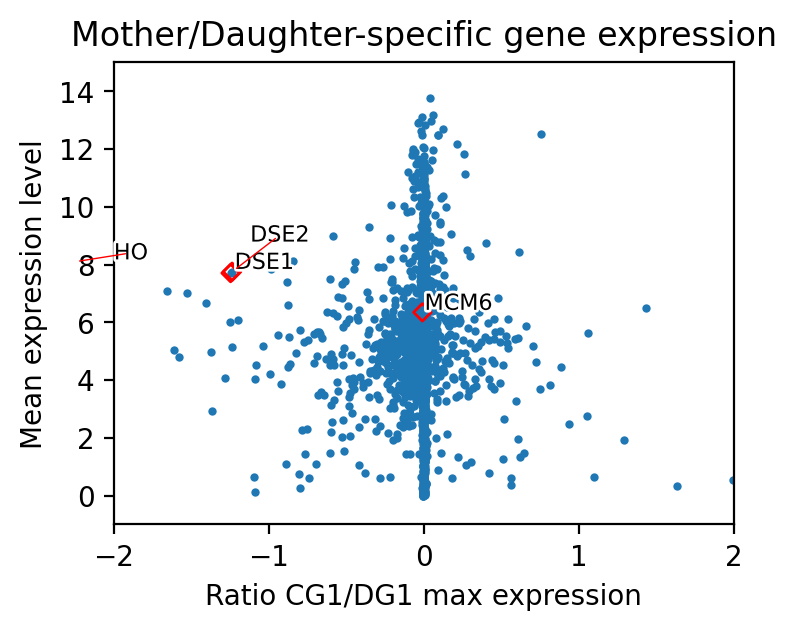

In [125]:
from src.CombinedReplicationDeconvolution import load_config_from_replication_runs
config1, config2 = load_config_from_replication_runs(output_directory, 4, mode='expression')

cg1_dg1_data = plot_volcano_cg1_dg1(deconvolved_genes_F, config1,
                                   genes_callout=['DSE1', 'DSE2', 'DSE3', 'DSE4',
                                                 'SIC1', 'MCM6', 'CLB2', 'CLN2',
                                                 'HO'])


In [254]:

def read_guo_gene(gene_name):
    guo_df = pd.read_csv('datasets/datasets_from_web_deconvolution.cs.duke.edu/deconvolved_profiles.tsv',
               sep='\t').set_index('SystematicName')
    C_cols = guo_df.columns[guo_df.columns.str.startswith('C')]
    D_cols = guo_df.columns[guo_df.columns.str.startswith('D')]
    from src.sgd import get_gene_name_orf_name
    
    orfname, gene_name = get_gene_name_orf_name(gene_name)
    deconvolved_data = guo_df.loc[orfname]
    
    return deconvolved_data[C_cols], deconvolved_data[D_cols]

def plot_comparison_guo_tt(gene_name):
    from src.sgd import get_orfname

    c_data, d_data = read_guo_gene(gene_name)
    orfname = get_orfname(gene_name)

    xs = np.arange(len(D_cols))

    plt.figure(figsize=(9, 3))
    plt.subplot(1, 2, 1)
    plt.plot(xs, c_data, label="Mother")
    plt.plot(xs, d_data, label="Daughter")
    plt.legend()

    xs = config1.get_timepoints_for_branch('t')
    plt.subplot(1, 2, 2)
    plt.plot(xs, deconvolved_genes_F.loc[orfname][config1.t_indices()])
    plt.plot(xs, deconvolved_genes_F.loc[orfname][config1.b_indices()])


In [181]:
from src.sgd import read_sgd_file
sgd_df = read_sgd_file()
sgd_df = sgd_df[sgd_df['cat'] == 'gene']

orf_names = sgd_df.desc.str.split(';', expand=True)[0].str.replace('ID=', '')
sgd_df.index = orf_names
sgd_df.index.name = 'orf_name'

In [244]:
# Create dataframes filtered by mother/daughter mentions
mother_df = sgd_df[sgd_df['desc'].str.contains('mother-sp', case=False, na=False)]
daughter_df = sgd_df[sgd_df['desc'].str.contains('daughter-sp', case=False, na=False)]

# Optional: Check for genes that appear in both lists
both_df = sgd_df[sgd_df['desc'].str.contains('mother-sp', case=False, na=False) & 
                sgd_df['desc'].str.contains('daughter-sp', case=False, na=False)]

mother_only_df = mother_df.loc[~mother_df.index.isin(both_df.index)]
daughter_only_df = daughter_df.loc[~daughter_df.index.isin(both_df.index)]

# Print summary information
print(f"Found {len(mother_only_df)} genes with 'mother' in description")
print(f"Found {len(daughter_only_df)} genes with 'daughter' in description")
print(f"Found {len(both_df)} genes with both 'mother' and 'daughter' in description")

daughter_desc_gene_names = genes.loc[daughter_only_df.index]['gene']
mother_desc_gene_names = genes.loc[mother_only_df.index]['gene']
both_gene_names = genes.loc[both_df.index]['gene']

Found 0 genes with 'mother' in description
Found 1 genes with 'daughter' in description
Found 0 genes with both 'mother' and 'daughter' in description


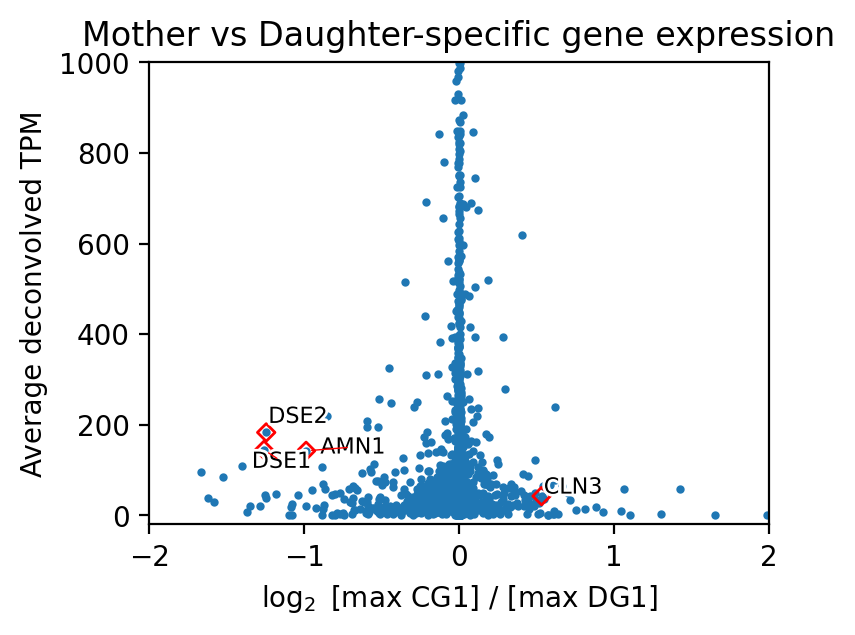

In [460]:
cg1_dg1_data = plot_volcano_cg1_dg1(deconvolved_genes_F, config1,
                                   genes_callout=
                                   ['DSE1', 'DSE2', 'AMN1', 'DSE3', 'CLN3', 'CTS1', 'ASH1'])


(0.0, 1.0)

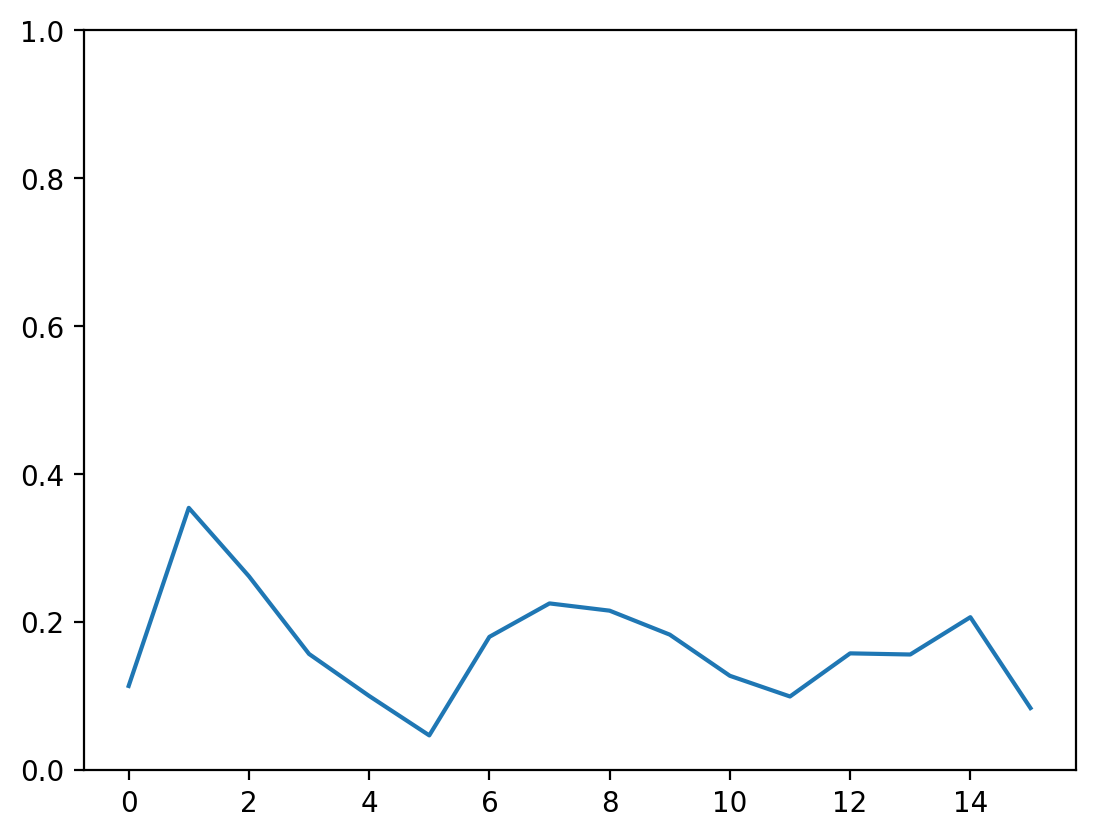

In [478]:
from src.gene_expression import load_gene_expression

plt.plot(load_gene_expression('YHR054C', 1))
plt.ylim(0, 1)

(0.0, 1.0)

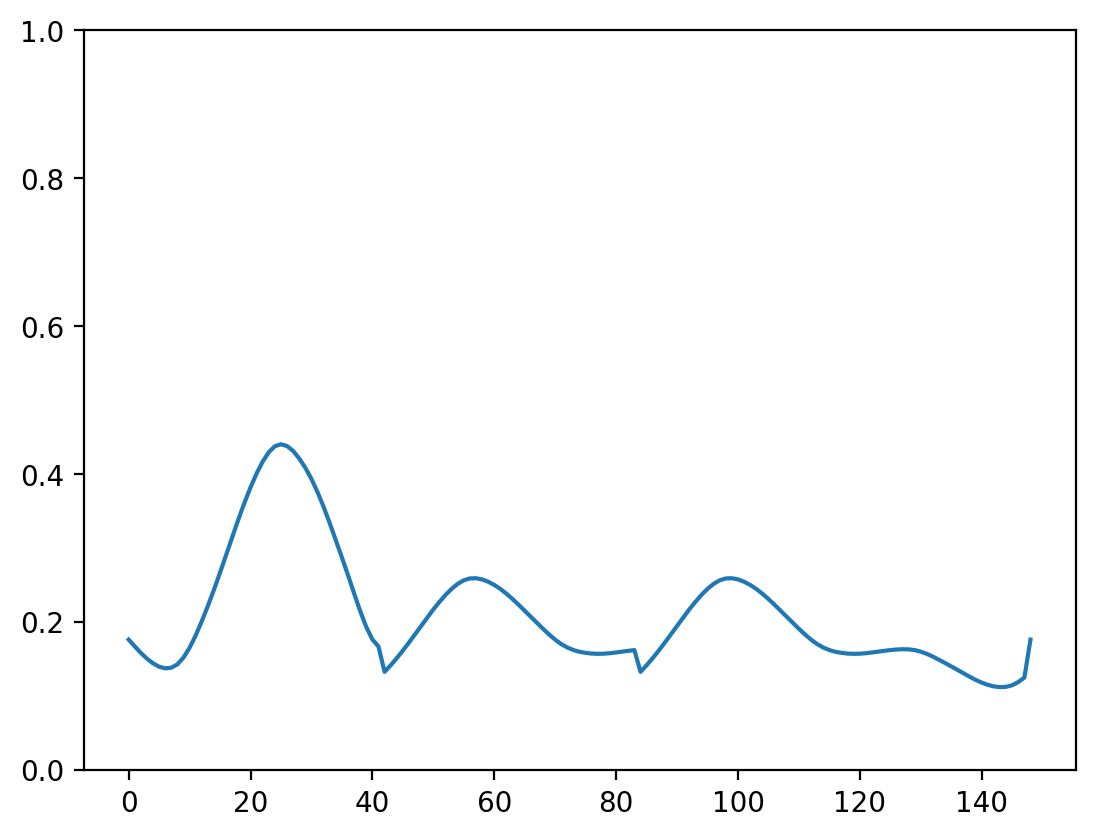

In [477]:
plt.plot(deconvolved_genes_F.loc['YHR054C'])
plt.ylim(0, 1)

In [480]:
a = genes.loc[deconvolved_genes_F.mean(axis=1).sort_values().head(100).index]
a[a['length'] > 500]

,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end,gene_idx
YIL015W,BAR1,9,gene,322342,324105,+,Verified,1763,322311,324182,False,322011.0,322311.0,322311.0,322811.0,2627
YGR273C,YGR273C,7,gene,1038715,1039239,-,Uncharacterized,524,1039239,1038715,NaN,1039239.0,1039539.0,1038739.0,1039239.0,2210
YHR054C,YHR054C,8,gene,213185,214249,-,Uncharacterized,1064,214249,213185,NaN,214249.0,214549.0,213749.0,214249.0,2325
YGL138C,YGL138C,7,gene,248494,249531,-,Uncharacterized,1037,249531,248494,NaN,249531.0,249831.0,249031.0,249531.0,1832
YDR522C,SPS2,4,gene,1483795,1485303,-,Verified,1508,1485303,1483795,NaN,1485303.0,1485603.0,1484803.0,1485303.0,1325
YFL040W,YFL040W,6,gene,51350,52972,+,Uncharacterized,1622,51350,52972,NaN,51050.0,51350.0,51350.0,51850.0,1623
YHL012W,YHL012W,8,gene,78936,80417,+,Uncharacterized,1481,78936,80417,NaN,78636.0,78936.0,78936.0,79436.0,2256
YJL043W,YJL043W,10,gene,360130,360903,+,Uncharacterized,773,359998,360903,False,359698.0,359998.0,359998.0,360498.0,2845
YDR446W,ECM11,4,gene,1353725,1354633,+,Verified,908,1353710,1354633,False,1353410.0,1353710.0,1353710.0,1354210.0,1254
YAL063C,FLO9,1,gene,24000,27968,-,Verified,3968,28212,23928,False,28212.0,28512.0,27712.0,28212.0,5


In [329]:
genes['gene_idx'] = np.arange(len(genes))
genes[genes['gene'] == 'CTS1']

from pipeline.CombinedDeconvolveGeneExpressionRunner import \
    CombinedDeconvolveGeneExpressionRunner

runner = CombinedDeconvolveGeneExpressionRunner('output/prototype_pipeline_subset/')

Shifting mu0, gamma1, and gamma2, for alpha...


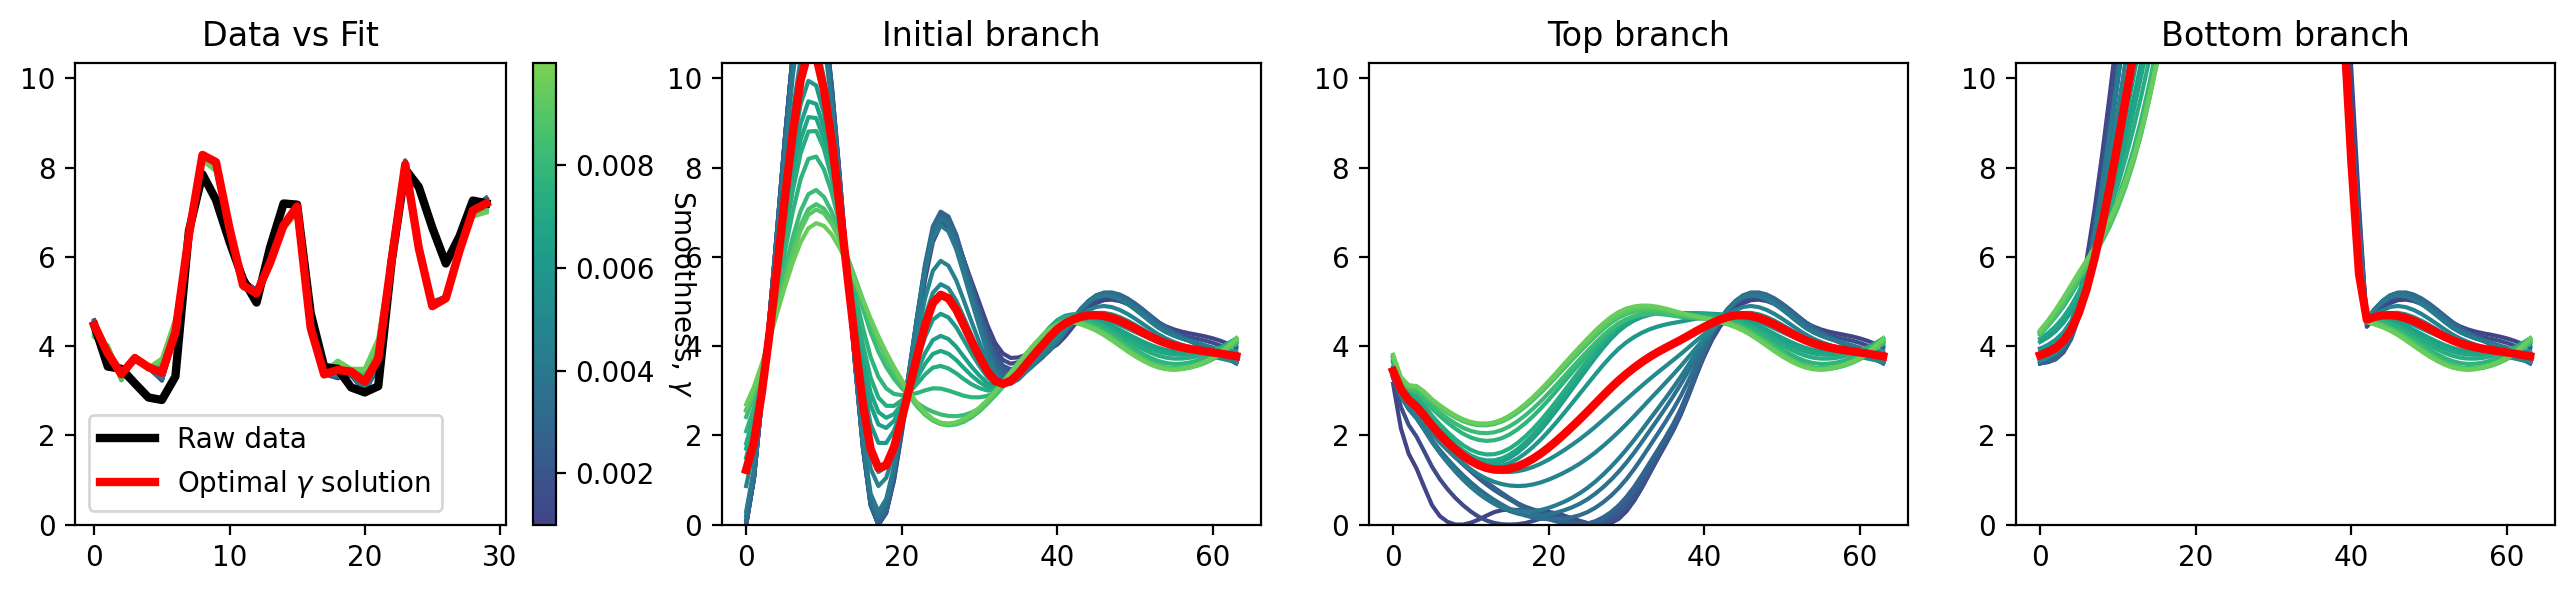

In [429]:
runner.deconvolve_gene('HO')
fig = runner.expression_find_gamma.plot_gamma_sweep()